**Buraya verisetinin ilk halinden biraz değişiklik yaptığımızı bahseden bir rapor yazısı eklenmeli**

In [102]:
import pandas as pd

df = pd.read_csv('/Users/safakelkit/Desktop/Desktop/Projects/Veri Bilimi/archive/customer_churn_dataset-training-master.csv')

ilk_5000 = df.head(5000)
son_5000 = df.tail(5000)

yeni_df = pd.concat([ilk_5000, son_5000])
yeni_df.to_excel("veriseti/train2.xlsx", index=False)

In [103]:
df = pd.read_excel("veriseti/train2.xlsx")

df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,3,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1
2,4,55,Female,14,4,6,18,Basic,Quarterly,185.0,3,1
3,5,58,Male,38,21,7,7,Standard,Monthly,396.0,29,1
4,6,23,Male,32,20,5,8,Basic,Monthly,617.0,20,1


In [104]:
df.shape

(10000, 12)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Gender             10000 non-null  object 
 3   Tenure             10000 non-null  int64  
 4   Usage Frequency    10000 non-null  int64  
 5   Support Calls      10000 non-null  int64  
 6   Payment Delay      10000 non-null  int64  
 7   Subscription Type  10000 non-null  object 
 8   Contract Length    10000 non-null  object 
 9   Total Spend        10000 non-null  float64
 10  Last Interaction   10000 non-null  int64  
 11  Churn              10000 non-null  int64  
dtypes: float64(1), int64(8), object(3)
memory usage: 937.6+ KB


In [106]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,224013.109700,38.667700,31.491000,15.937500,3.265400,12.576600,652.193051,14.248300,0.480000
std,221520.921762,12.062331,17.265171,8.525108,2.967464,8.009966,230.049477,8.510364,0.499625
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,2508.750000,29.000000,17.000000,9.000000,1.000000,6.000000,519.565000,7.000000,0.000000
50%,223978.000000,39.000000,32.000000,16.000000,2.000000,12.000000,678.515000,13.000000,0.000000
75%,445447.250000,47.000000,46.000000,23.000000,5.000000,18.000000,840.970000,21.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [107]:
df.select_dtypes(include="object").columns


Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='object')

In [108]:
df["Churn"].value_counts(normalize=True) * 100


Churn
0    52.0
1    48.0
Name: proportion, dtype: float64

In [109]:
df.duplicated().sum()


np.int64(0)

In [110]:
df_model = df.copy()

In [111]:
df_model.drop("CustomerID", axis=1, inplace=True)

In [112]:
df_model.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1
2,55,Female,14,4,6,18,Basic,Quarterly,185.0,3,1
3,58,Male,38,21,7,7,Standard,Monthly,396.0,29,1
4,23,Male,32,20,5,8,Basic,Monthly,617.0,20,1


In [113]:
df_model["Gender"] = df_model["Gender"].map({
    "Male": 1,
    "Female": 0
})

In [ ]:
df_model["Contract Length"] = df_model["Contract Length"].map({
    "Monthly": 0,
    "Quarterly": 1,
    "Annual": 2
})

In [115]:
df_model = pd.get_dummies(
    df_model,
    columns=["Subscription Type"],
    drop_first=True
)

In [116]:
pd.get_dummies(df["Subscription Type"])

,Basic,Premium,Standard
0,False,False,True
1,True,False,False
2,True,False,False
3,False,False,True
4,True,False,False
...,...,...,...
9995,False,True,False
9996,False,True,False
9997,False,False,True
9998,False,False,True


In [117]:
df_model.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Contract Length,Total Spend,Last Interaction,Churn,Subscription Type_Premium,Subscription Type_Standard
0,30,0,39,14,5,18,2,932.0,17,1,False,True
1,65,0,49,1,10,8,0,557.0,6,1,False,False
2,55,0,14,4,6,18,1,185.0,3,1,False,False
3,58,1,38,21,7,7,0,396.0,29,1,False,True
4,23,1,32,20,5,8,0,617.0,20,1,False,False


In [118]:
x = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

In [119]:
print(x.shape)
print(y.shape)

(10000, 11)
(10000,)


In [120]:
x.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Contract Length', 'Total Spend', 'Last Interaction',
       'Subscription Type_Premium', 'Subscription Type_Standard'],
      dtype='object')

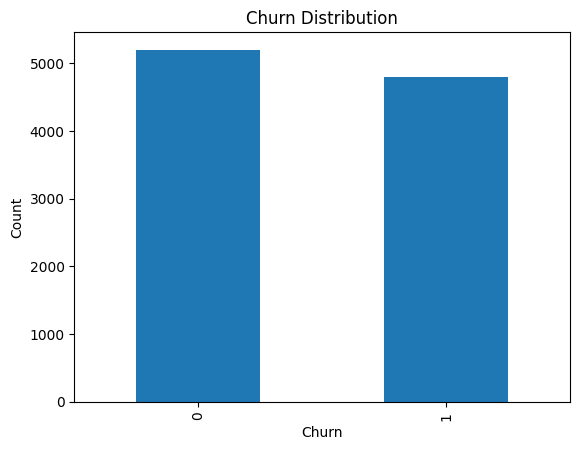

In [121]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

/var/folders/st/8smpkhnn64x8m8c1rr3p_q9h0000gn/T/ipykernel_19274/4017331171.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


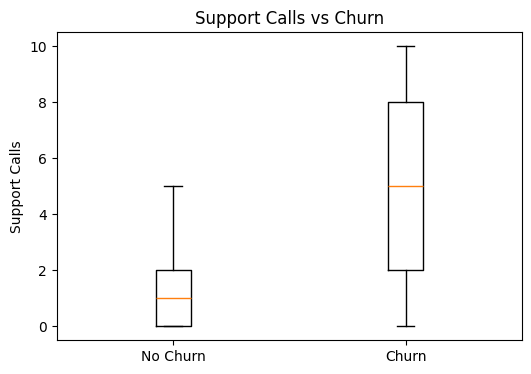

In [122]:
plt.figure(figsize=(6,4))
plt.boxplot(
    [x[y==0]["Support Calls"], x[y==1]["Support Calls"]],
    labels=["No Churn", "Churn"]
)
plt.title("Support Calls vs Churn")
plt.ylabel("Support Calls")
plt.show()

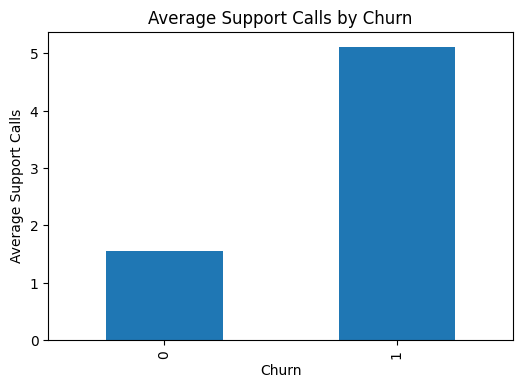

In [123]:
mean_support = x.groupby(y)["Support Calls"].mean()

mean_support.plot(kind="bar", figsize=(6,4))
plt.title("Average Support Calls by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Support Calls")
plt.show()


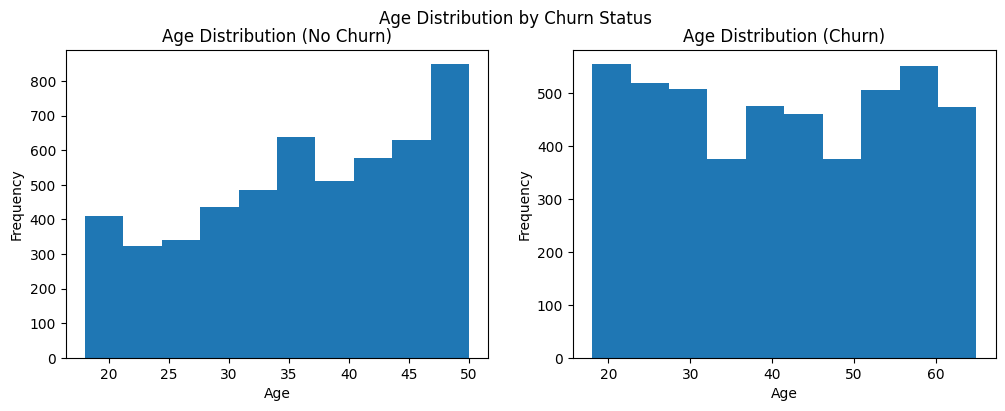

In [124]:
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.hist(x[y == 0]["Age"], bins=10)
plt.title("Age Distribution (No Churn)")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(x[y == 1]["Age"], bins=10)
plt.title("Age Distribution (Churn)")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.suptitle("Age Distribution by Churn Status")
plt.show()


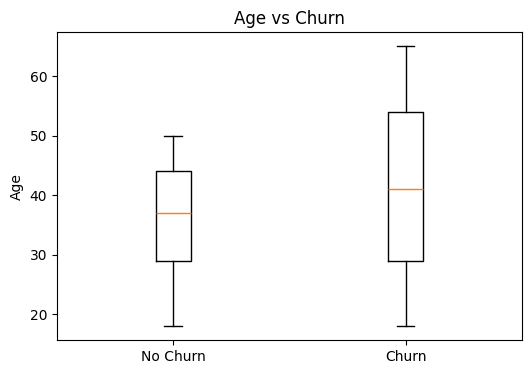

In [125]:
plt.figure(figsize=(6,4))
plt.boxplot(
    [x[y == 0]["Age"], x[y == 1]["Age"]],
    tick_labels=["No Churn", "Churn"]
)
plt.title("Age vs Churn")
plt.ylabel("Age")
plt.show()


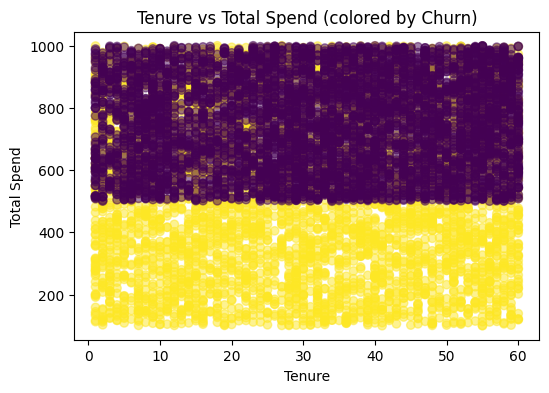

In [126]:
plt.figure(figsize=(6,4))
plt.scatter(
    x["Tenure"],
    x["Total Spend"],
    c=y,
    alpha=0.5
)
plt.xlabel("Tenure")
plt.ylabel("Total Spend")
plt.title("Tenure vs Total Spend (colored by Churn)")
plt.show()


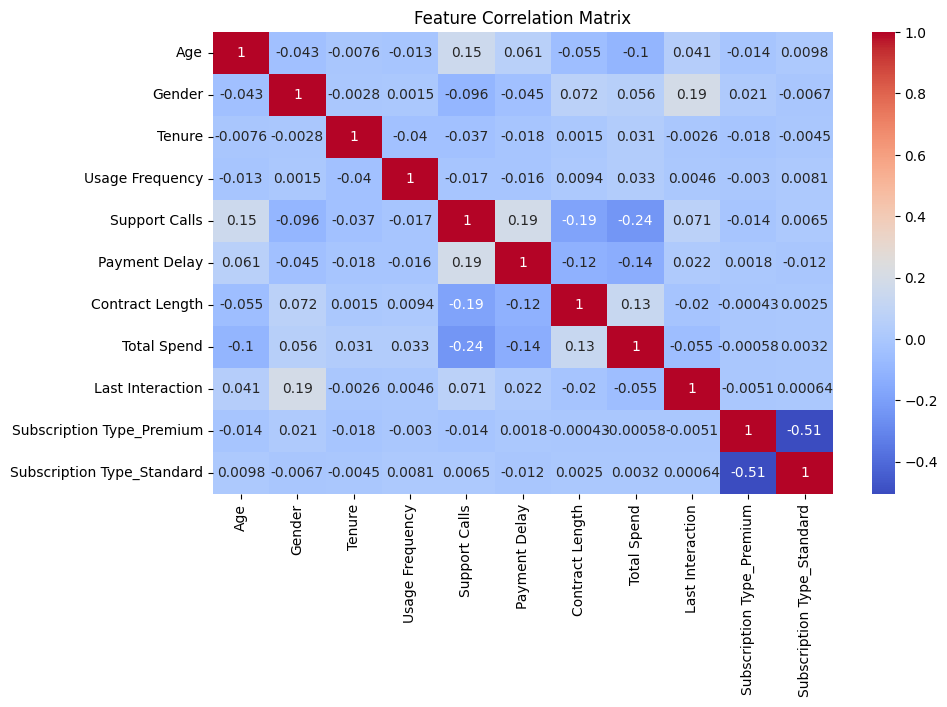

In [127]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(
    x.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Matrix")
plt.show()


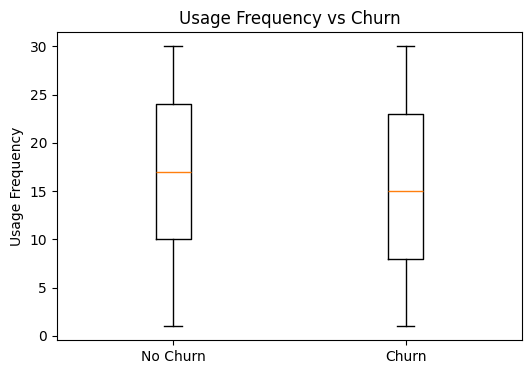

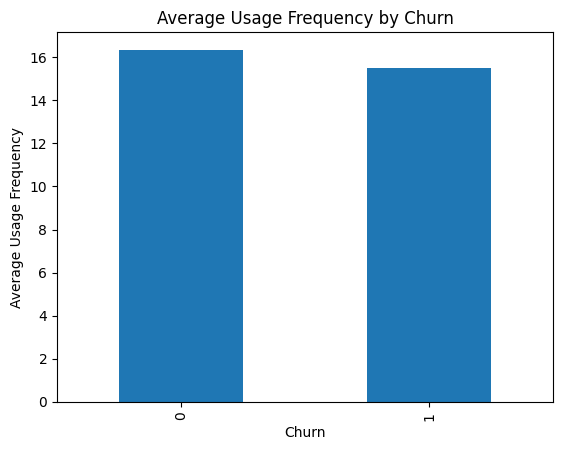

In [128]:
plt.figure(figsize=(6,4))
plt.boxplot(
    [x[y==0]["Usage Frequency"], x[y==1]["Usage Frequency"]],
    tick_labels=["No Churn", "Churn"]
)
plt.title("Usage Frequency vs Churn")
plt.ylabel("Usage Frequency")
plt.show()

x.groupby(y)["Usage Frequency"].mean().plot(kind="bar")
plt.title("Average Usage Frequency by Churn")
plt.ylabel("Average Usage Frequency")
plt.show()


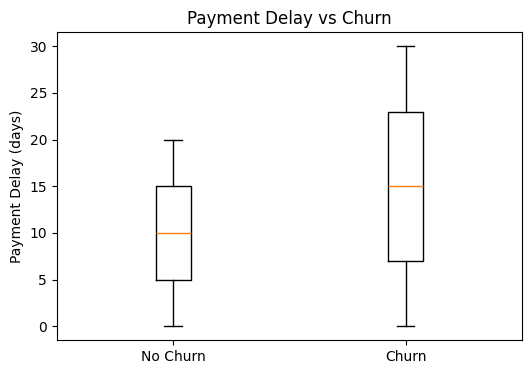

In [129]:
plt.figure(figsize=(6,4))
plt.boxplot(
    [x[y==0]["Payment Delay"], x[y==1]["Payment Delay"]],
    tick_labels=["No Churn", "Churn"]
)
plt.title("Payment Delay vs Churn")
plt.ylabel("Payment Delay (days)")
plt.show()


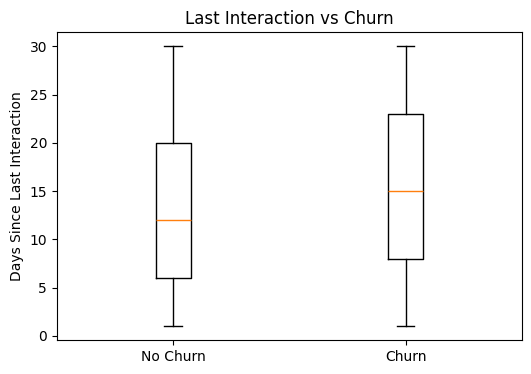

In [130]:
plt.figure(figsize=(6,4))
plt.boxplot(
    [x[y==0]["Last Interaction"], x[y==1]["Last Interaction"]],
    tick_labels=["No Churn", "Churn"]
)
plt.title("Last Interaction vs Churn")
plt.ylabel("Days Since Last Interaction")
plt.show()


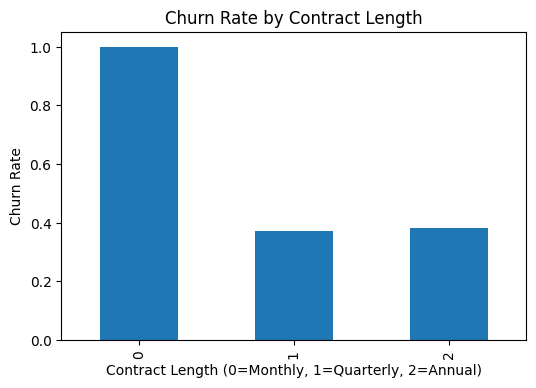

In [131]:
contract_churn = df_model.groupby("Contract Length")["Churn"].mean()

contract_churn.plot(kind="bar", figsize=(6,4))
plt.title("Churn Rate by Contract Length")
plt.ylabel("Churn Rate")
plt.xlabel("Contract Length (0=Monthly, 1=Quarterly, 2=Annual)")
plt.show()


In [132]:
monthly_df = df_model[df_model["Contract Length"] == 0]

monthly_df["Churn"].value_counts()

Churn
1    1670
Name: count, dtype: int64

In [133]:
monthly_df[["Contract Length", "Churn"]].head(10)

,Contract Length,Churn
1,0,1
3,0,1
4,0,1
11,0,1
18,0,1
21,0,1
23,0,1
24,0,1
29,0,1
31,0,1


In [134]:
monthly_df["Churn"].value_counts(normalize=True) * 100

Churn
1    100.0
Name: proportion, dtype: float64

In [136]:
x.describe()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Contract Length,Total Spend,Last Interaction
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,38.667700,0.583700,31.491000,15.937500,3.265400,12.576600,1.244100,652.193051,14.248300
std,12.062331,0.492969,17.265171,8.525108,2.967464,8.009966,0.720116,230.049477,8.510364
min,18.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,100.000000,1.000000
25%,29.000000,0.000000,17.000000,9.000000,1.000000,6.000000,1.000000,519.565000,7.000000
50%,39.000000,1.000000,32.000000,16.000000,2.000000,12.000000,1.000000,678.515000,13.000000
75%,47.000000,1.000000,46.000000,23.000000,5.000000,18.000000,2.000000,840.970000,21.000000
max,65.000000,1.000000,60.000000,30.000000,10.000000,30.000000,2.000000,1000.000000,30.000000


In [137]:
stats_df = pd.DataFrame({
    "Mean": x.mean(),
    "Median": x.median(),
    "Mode": x.mode().iloc[0]
})

stats_df


,Mean,Median,Mode
Age,38.667700,39.000,48.0
Gender,0.583700,1.000,1.0
Tenure,31.491000,32.000,55.0
Usage Frequency,15.937500,16.000,13.0
Support Calls,3.265400,2.000,0.0
Payment Delay,12.576600,12.000,14.0
Contract Length,1.244100,1.000,1.0
Total Spend,652.193051,678.515,426.0
Last Interaction,14.248300,13.000,4.0
Subscription Type_Premium,0.339400,0.000,False


In [138]:
import numpy as np

x_num = x.select_dtypes(include=[np.number])

variability_df = pd.DataFrame({
    "Variance": x_num.var(),
    "Std Dev": x_num.std(),
    "Range": x_num.max() - x_num.min()
})

variability_df


,Variance,Std Dev,Range
Age,145.499827,12.062331,47.0
Gender,0.243019,0.492969,1.0
Tenure,298.086128,17.265171,59.0
Usage Frequency,72.677461,8.525108,29.0
Support Calls,8.805843,2.967464,10.0
Payment Delay,64.159548,8.009966,30.0
Contract Length,0.518567,0.720116,2.0
Total Spend,52922.761714,230.049477,900.0
Last Interaction,72.426290,8.510364,29.0


In [139]:
from scipy.stats import skew, kurtosis

x_num = x.select_dtypes(include=[np.number])

distribution_df = pd.DataFrame({
    "Skewness": x_num.apply(skew),
    "Kurtosis": x_num.apply(kurtosis)
})

distribution_df


,Skewness,Kurtosis
Age,0.181779,-0.788892
Gender,-0.339592,-1.884677
Tenure,-0.082883,-1.173425
Usage Frequency,-0.055353,-1.150298
Support Calls,0.859590,-0.378443
Payment Delay,0.305017,-0.782029
Contract Length,-0.402154,-1.007180
Total Spend,-0.549182,-0.509874
Last Interaction,0.212234,-1.117860


In [ ]:
x_num = x.select_dtypes(include=[np.number])

percentiles = x_num.quantile([0.25, 0.5, 0.75])
percentiles

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Contract Length,Total Spend,Last Interaction
0.25,29.0,0.0,17.0,9.0,1.0,6.0,1.0,519.565,7.0
0.50,39.0,1.0,32.0,16.0,2.0,12.0,1.0,678.515,13.0
0.75,47.0,1.0,46.0,23.0,5.0,18.0,2.0,840.970,21.0


In [ ]:
x.groupby(y).agg(["mean", "median", "std"])

Age                      Gender                      Tenure  \
            mean median        std      mean median       std       mean   
Churn                                                                      
0      36.307885   37.0   9.212982  0.671923    1.0  0.469558  32.202115   
1      41.224167   41.0  14.093715  0.488125    0.0  0.499911  30.720625   

                        Usage Frequency  ... Total Spend Last Interaction  \
      median        std            mean  ...         std             mean   
Churn                                    ...                                
0       33.0  16.996739       16.340577  ...  144.805668        13.188077   
1       31.0  17.520567       15.500833  ...  257.489812        15.396875   

                       Subscription Type_Premium                   \
      median       std                      mean median       std   
Churn                                                               
0       12.0  8.271783                  0.345192    0.0  0.475477   
1       15.0  8.616351                  0.333125    0.0  0.471380   

      Subscription Type_Standard                   
                            mean median       std  
Churn                                              
0                       0.335577    0.0  0.472237  
1                       0.329792    0.0  0.470186  

[2 rows x 33 columns]

In [142]:
selected_features = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Contract Length",
    "Total Spend",
    "Last Interaction",
    "Subscription Type_Standard",
    "Subscription Type_Premium",
]

x_selected = x[selected_features]
y=y

In [143]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [145]:
from sklearn.linear_model import LogisticRegression

lr_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_baseline.fit(x_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [177]:
import joblib

joblib.dump(lr_baseline, "logistic_model.joblib")

print("Logistic Regression modeli kaydedildi.")


Logistic Regression modeli kaydedildi.


In [ ]:
y_pred = lr_baseline.predict(x_test)

In [150]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)


Accuracy : 0.861
Precision: 0.8974358974358975
Recall   : 0.8020833333333334
F1-score : 0.847084708470847


In [151]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm


array([[952,  88],
       [190, 770]])

In [162]:
coef_df = pd.DataFrame({
    "feature": x_train.columns,
    "coefficient": lr_baseline.coef_[0]
}).sort_values(by="coefficient", ascending=False)

coef_df


,feature,coefficient
3,Support Calls,0.719372
4,Payment Delay,0.102366
7,Last Interaction,0.037154
0,Age,0.028197
1,Tenure,-0.003492
6,Total Spend,-0.005654
2,Usage Frequency,-0.017180
9,Subscription Type_Premium,-0.091725
8,Subscription Type_Standard,-0.103951
5,Contract Length,-1.371884


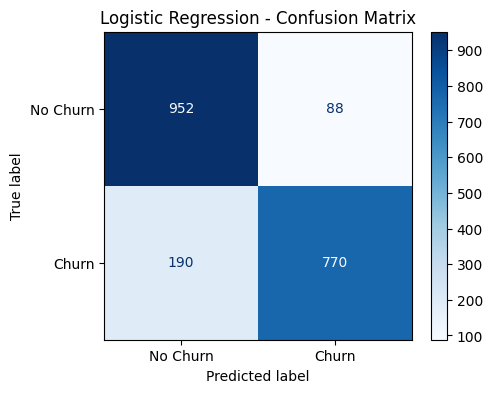

In [163]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])

fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


In [165]:
y_proba = lr_baseline.predict_proba(x_test)[:, 1]

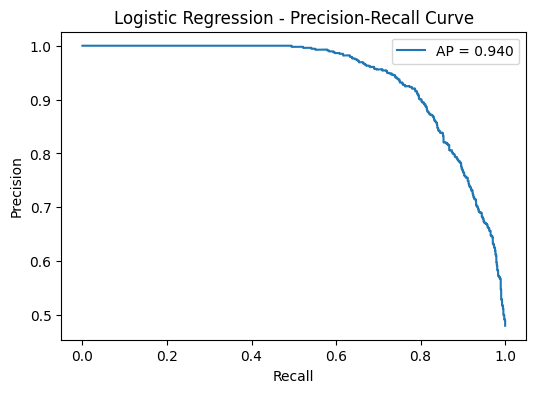

In [166]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression - Precision-Recall Curve")
plt.legend()
plt.show()

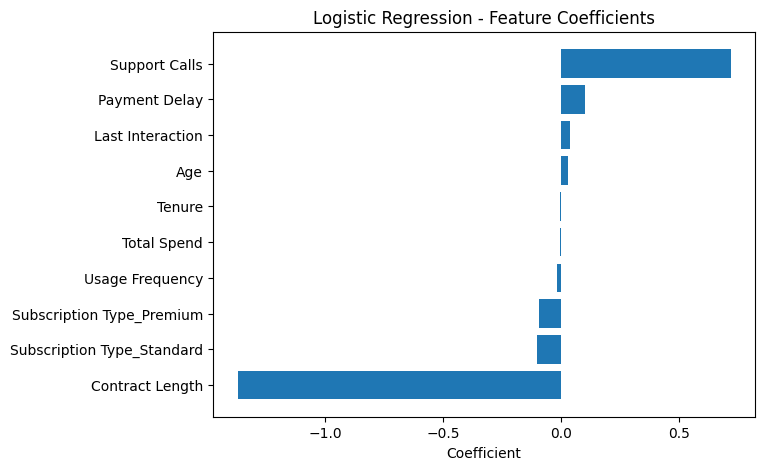

In [168]:
import pandas as pd
import numpy as np

coef_df = pd.DataFrame({
    "Feature": x_selected.columns,
    "Coefficient": lr_baseline.coef_[0]
}).sort_values("Coefficient")

plt.figure(figsize=(7,5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.xlabel("Coefficient")
plt.title("Logistic Regression - Feature Coefficients")
plt.show()


In [153]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.7,
    subsample=0.3,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(x_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.7, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [176]:
import joblib, json

joblib.dump(xgb_model, "xgboost_model.joblib")

feature_cols = list(x_train.columns)
with open("feature_columns.json", "w") as f:
    json.dump(feature_cols, f)

print("XGBoost modeli kaydedildi.")


XGBoost modeli kaydedildi.


In [154]:
y_pred_xgb = xgb_model.predict(x_test)


In [155]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("Accuracy :", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1-score :", f1_xgb)


XGBoost Results
Accuracy : 0.9685
Precision: 0.975609756097561
Recall   : 0.9583333333333334
F1-score : 0.9668943772990016


In [156]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_xgb


array([[1017,   23],
       [  40,  920]])

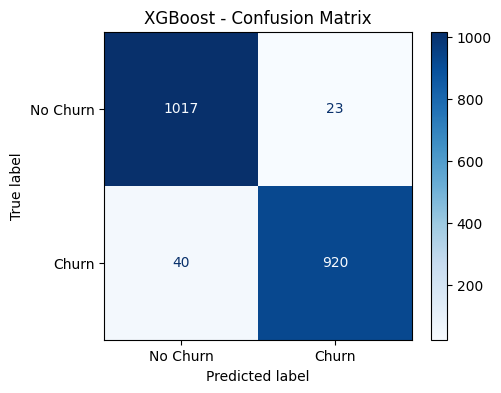

In [169]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["No Churn", "Churn"]
)

fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("XGBoost - Confusion Matrix")
plt.show()


In [170]:
y_proba_xgb = xgb_model.predict_proba(x_test)[:, 1]

In [171]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(
    y_test, y_proba_xgb
)

ap_xgb = average_precision_score(y_test, y_proba_xgb)


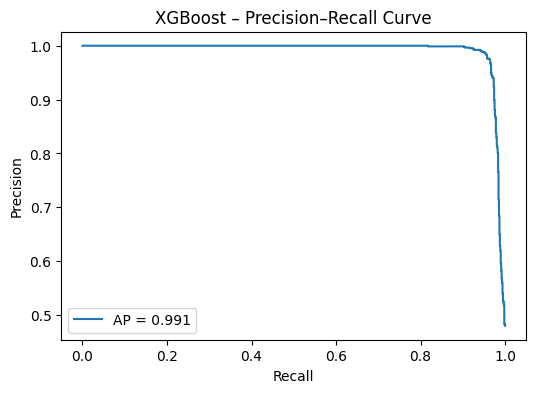

In [172]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(recall_xgb, precision_xgb, label=f"AP = {ap_xgb:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost – Precision–Recall Curve")
plt.legend()
plt.show()


In [157]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression (Baseline)", "XGBoost"],
    "Accuracy": [accuracy, accuracy_xgb],
    "Precision": [precision, precision_xgb],
    "Recall": [recall, recall_xgb],
    "F1-score": [f1, f1_xgb]
})

comparison_df


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression (Baseline),0.8610,0.897436,0.802083,0.847085
1,XGBoost,0.9685,0.975610,0.958333,0.966894


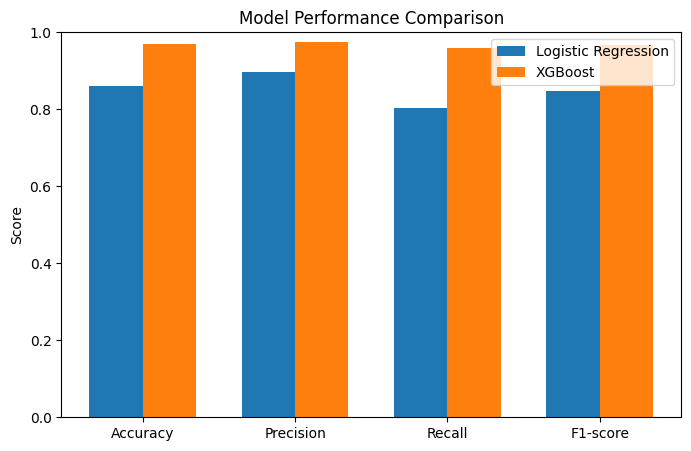

In [175]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

lr_scores = comparison_df.loc[0, metrics].values
xgb_scores = comparison_df.loc[1, metrics].values

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, lr_scores, width, label="Logistic Regression")
plt.bar(x + width/2, xgb_scores, width, label="XGBoost")

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()
